<p align="center" style="font-size:24px;"><b>HW 3 - Time Series Classification [Part 1]</b></p>


## 1. Time Series Classification Part 1: Feature Creation/Extraction

### (a) Download Data

Package imports

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from scipy.stats import bootstrap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import SelectKBest, f_classif

Get the AReM Data Set

In [2]:
root = "../data/AReM/"
folders = ["bending1", "bending2", "cycling", "lying", "sitting", "standing", "walking"]
headers = ["time", "avg_rss12","var_rss12","avg_rss13","var_rss13","avg_rss23","var_rss23"]
label_map = {"bending1": 0, "bending2": 1, "cycling": 2, "lying": 3, "sitting": 4, "standing": 5, "walking": 6}

### (b) Test and Train Data

In [3]:
def read_csv(path):
    with open(path, "r") as f:
        lines = f.readlines()

    # Skip the fist 5 lines, check the first line with data
    # Set up the seperator of the file accordingly
    first_data_line = lines[5]
    sep = "," if "," in first_data_line else r"\s+"

    df = pd.read_csv(
        path,
        sep=sep,
        engine="python",
        skiprows=5,
        header=None,
        names=headers
    )
    
    return df

In [4]:
X_train, y_train, X_test, y_test = [], [], [], []

for folder in folders:
    # Load first k datasets as test data
    k = 2 if (folder == "bending1" or folder == "bending2") else 3

    for i in range(1, k+1):
        path = path = Path(root) / folder / f"dataset{i}.csv"
        X_test.append(read_csv(path))
        y_test.append(label_map[folder])
        
    for i in range(k+1, 16):
        path = Path(root) / folder / f"dataset{i}.csv"
        # There will be at most 15 datasets in the folder, some of the folders contain less than 15 datasets
        if path.exists():
            X_train.append(read_csv(path))
            y_train.append(label_map[folder])
    

print("Train set:", len(X_train), "samples")
print("Test set:", len(X_test), "samples")
print("Train labels:", len(y_train))
print("Test labels:", len(y_test))

print("\nSample shapes:")
print("First train sample shape:", X_train[0].shape)
print("First test sample shape:", X_test[0].shape)

# Check if there are dataset whose shape is not (480,7)
unique_train_shapes = set(df.shape for df in X_train)
unique_test_shapes = set(df.shape for df in X_test)
print("Unique train shapes:", unique_train_shapes)
print("Unique test shapes:", unique_test_shapes)

print("\nSample format:")
print(X_train[0].head())


Train set: 69 samples
Test set: 19 samples
Train labels: 69
Test labels: 19

Sample shapes:
First train sample shape: (480, 7)
First test sample shape: (480, 7)
Unique train shapes: {(479, 7), (480, 7)}
Unique test shapes: {(480, 7)}

Sample format:
   time  avg_rss12  var_rss12  avg_rss13  var_rss13  avg_rss23  var_rss23
0     0      42.00       0.71      21.25       0.43      30.00       0.00
1   250      41.50       0.50      20.25       1.48      31.25       1.09
2   500      41.50       0.50      14.25       1.92      33.00       0.00
3   750      40.75       0.83      15.75       0.43      33.00       0.00
4  1000      40.00       0.71      20.00       2.74      32.75       0.43


### (c) Feature Extraction

#### i. Research

Time-domain features are usually used in time series classification:
- Mean
- Maximum
- Minimum
- Median
- First quartile
- Third quartile
- Variance
- Standard deviation
- Skewness
- Kurtosis
- Zero Crossing Rate
- Volatility

#### ii. Extraction

Extract the time-domain features minimum, maximum, mean, median, standard deviation, first quartile, and third quartile for all of the 6 time series in each instance.

In [5]:
def extract_time_features(df):
    feature_cols = df.columns[1:] # Ignore time
    features = []

    for col in feature_cols:
        data = df[col].dropna()
        features.extend([
            data.min(),
            data.max(),
            data.mean(),
            data.median(),
            data.std(),
            np.percentile(data, 25),
            np.percentile(data, 75)
        ])
    
    return features

In [6]:
X_train_features = np.array([extract_time_features(df) for df in X_train])
X_test_features  = np.array([extract_time_features(df) for df in X_test])
y_train = np.array(y_train)
y_test = np.array(y_test)

print("Train feature shape:", X_train_features.shape)
print("Test feature shape:", X_test_features.shape)

Train feature shape: (69, 42)
Test feature shape: (19, 42)


In [7]:
stats = ["min", "max", "mean", "median", "std", "q1", "q3"]

feature_names = [f"{stat}_{i}" for i in range(1, 7) for stat in stats]

df_train = pd.DataFrame(X_train_features, columns=feature_names)
df_train["label"] = y_train

df_train.head()

,min_1,max_1,mean_1,median_1,std_1,q1_1,q3_1,min_2,max_2,mean_2,...,q1_5,q3_5,min_6,max_6,mean_6,median_6,std_6,q1_6,q3_6,label
0,35.00,47.40,43.954500,44.33,1.558835,43.00,45.00,0.0,1.70,0.426250,...,35.3625,36.50,0.0,1.79,0.493292,0.43,0.513506,0.00,0.94,0
1,33.00,47.75,42.179812,43.50,3.670666,39.15,45.00,0.0,3.00,0.696042,...,30.4575,36.33,0.0,2.18,0.613521,0.50,0.524317,0.00,1.00,0
2,33.00,45.75,41.678063,41.75,2.243490,41.33,42.75,0.0,2.83,0.535979,...,28.4575,31.25,0.0,1.79,0.383292,0.43,0.389164,0.00,0.50,0
3,37.00,48.00,43.454958,43.25,1.386098,42.50,45.00,0.0,1.58,0.378083,...,22.2500,24.00,0.0,5.26,0.679646,0.50,0.622534,0.43,0.87,0
4,36.25,48.00,43.969125,44.50,1.618364,43.31,44.67,0.0,1.50,0.413125,...,20.5000,23.75,0.0,2.96,0.555312,0.49,0.487826,0.00,0.83,0


From the sample of the raw feature table above, we can see that the features are in different numerical scales. This could increase bias in the learning process because features with higher scales like mean_1(43.95) will dominate features with lower scales like mean_2(0.43). The result model will interpret features with higher scales as more important caused by its higher value than others.
 
So we want to standardize the data to let each feature contributes equally to the following learning process.

In [8]:
# Create the scaler to standardize the data
scaler = StandardScaler()
X_train_features_scaled = scaler.fit_transform(X_train_features)
X_test_features_scaled = scaler.transform(X_test_features)

# Generate the scaled train and test dataframes
df_train_scaled = pd.DataFrame(X_train_features_scaled, columns=feature_names)
df_train_scaled["label"] = y_train
df_test_scaled = pd.DataFrame(X_test_features_scaled, columns=feature_names)
df_test_scaled["label"] = y_test

df_train_scaled.head()

,min_1,max_1,mean_1,median_1,std_1,q1_1,q3_1,min_2,max_2,mean_2,...,q1_5,q3_5,min_6,max_6,mean_6,median_6,std_6,q1_6,q3_6,label
0,0.634436,0.449552,1.013755,1.115470,-0.823770,1.060985,0.768545,0.0,-0.908718,-0.682133,...,3.978714,3.726088,-0.121268,-1.864173,-0.989620,-0.955662,-1.035636,-1.204332,-0.792705,0
1,0.405350,0.529152,0.650234,0.946774,0.385867,0.384309,0.768545,0.0,-0.654335,-0.512348,...,3.087473,3.691543,-0.121268,-1.709515,-0.886223,-0.891828,-1.014668,-1.204332,-0.753717,0
2,0.405350,0.074294,0.547458,0.591087,-0.431606,0.767466,0.294747,0.0,-0.687600,-0.613078,...,2.724072,2.659270,-0.121268,-1.864173,-1.084220,-0.955662,-1.276795,-1.204332,-1.078615,0
3,0.863522,0.586010,0.911430,0.895961,-0.922712,0.973105,0.768545,0.0,-0.932199,-0.712445,...,1.596166,1.186045,-0.121268,-0.488113,-0.829355,-0.891828,-0.824177,-0.644875,-0.838190,0
4,0.777615,0.586010,1.016750,1.150023,-0.789673,1.115470,0.699055,0.0,-0.947854,-0.690393,...,1.278191,1.135244,-0.121268,-1.400199,-0.936282,-0.900947,-1.085441,-1.204332,-0.864182,0


#### iii. Standard Deviation

For the experiment purpose, we will calculate the standard deviation and build 90% bootstap confidence interval based on both raw and standardized data.

In [9]:
# Calculate all the standard deviation of the raw time-domain features
feature_stds = df_train.drop(columns="label").std()

print("Sample result for standard deviation of raw features of avg_rss12:")
print(feature_stds.head(7))

Sample result for standard deviation of raw features of avg_rss12:
min_1       8.794295
max_1       4.429182
mean_1      4.917717
median_1    4.956111
std_1       1.758629
q1_1        5.731262
q3_1        4.783645
dtype: float64


In [10]:
# Calculate all the standard deviation of the standardized time-domain features
scaled_feature_stds = df_train_scaled.drop(columns="label").std()

print("Sample result for standard deviation of standardized features of avg_rss12:")
print(scaled_feature_stds.head(7))

Sample result for standard deviation of standardized features of avg_rss12:
min_1       1.007326
max_1       1.007326
mean_1      1.007326
median_1    1.007326
std_1       1.007326
q1_1        1.007326
q3_1        1.007326
dtype: float64


Now we calculate the 90% confidence interval for the standard deviation of each feature.

In [11]:
X_raw = df_train.drop(columns="label")
X_scaled = df_train_scaled.drop(columns="label")

# Define statistic of bootstrap method
def std_statistic(data, axis):
    return np.std(data, axis=axis, ddof=1)

# Bootstrap parameters
confidence = 0.90
n_resamples = 10000

results_raw = {}
results_scaled = {}

# Bootstrap on raw data
for col in X_raw.columns:
    res = bootstrap(
        [X_raw[col].values,],
        std_statistic,
        confidence_level=confidence,
        n_resamples=n_resamples,
        random_state=21,
        method='percentile'
    )
    results_raw[col] = {
        "std": np.std(X_raw[col].values, ddof=1),
        "ci_low": res.confidence_interval.low,
        "ci_high": res.confidence_interval.high
    }

# Bootstrap on standardized data
for col in X_scaled.columns:
    res = bootstrap(
        [X_scaled[col].values,],
        std_statistic,
        confidence_level=confidence,
        n_resamples=n_resamples,
        random_state=21,
        method='percentile'
    )
    results_scaled[col] = {
        "std": np.std(X_scaled[col].values, ddof=1),
        "ci_low": res.confidence_interval.low,
        "ci_high": res.confidence_interval.high
    }

# Compare the results between raw and scaled data
df_compare = pd.DataFrame({
    "raw_std": [results_raw[c]["std"] for c in X_raw.columns],
    "raw_ci_low": [results_raw[c]["ci_low"] for c in X_raw.columns],
    "raw_ci_high": [results_raw[c]["ci_high"] for c in X_raw.columns],
    "scaled_std": [results_scaled[c]["std"] for c in X_scaled.columns],
    "scaled_ci_low": [results_scaled[c]["ci_low"] for c in X_scaled.columns],
    "scaled_ci_high": [results_scaled[c]["ci_high"] for c in X_scaled.columns],
}, index=X_raw.columns)

df_compare.head(14)

,raw_std,raw_ci_low,raw_ci_high,scaled_std,scaled_ci_low,scaled_ci_high
min_1,8.794295,7.520654,10.054518,1.007326,0.861439,1.151676
max_1,4.429182,3.276581,5.417495,1.007326,0.745191,1.232098
mean_1,4.917717,4.323265,5.433472,1.007326,0.885561,1.112972
median_1,4.956111,4.334821,5.496132,1.007326,0.881049,1.117085
std_1,1.758629,1.543848,1.943921,1.007326,0.884301,1.113460
q1_1,5.731262,5.142760,6.215587,1.007326,0.903891,1.092451
q3_1,4.783645,3.923638,5.537083,1.007326,0.826228,1.165983
min_2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max_2,5.147841,4.663553,5.517190,1.007326,0.912561,1.079600
mean_2,1.600661,1.401746,1.738766,1.007326,0.882145,1.094238


#### iv. Select Features

We want to select the three most important time-domain features.

First we plot the boxplot of each feature to check the distribution of the feature across different types of movement. For the features with wider spread boxes are more likely to reflect the type of data better.

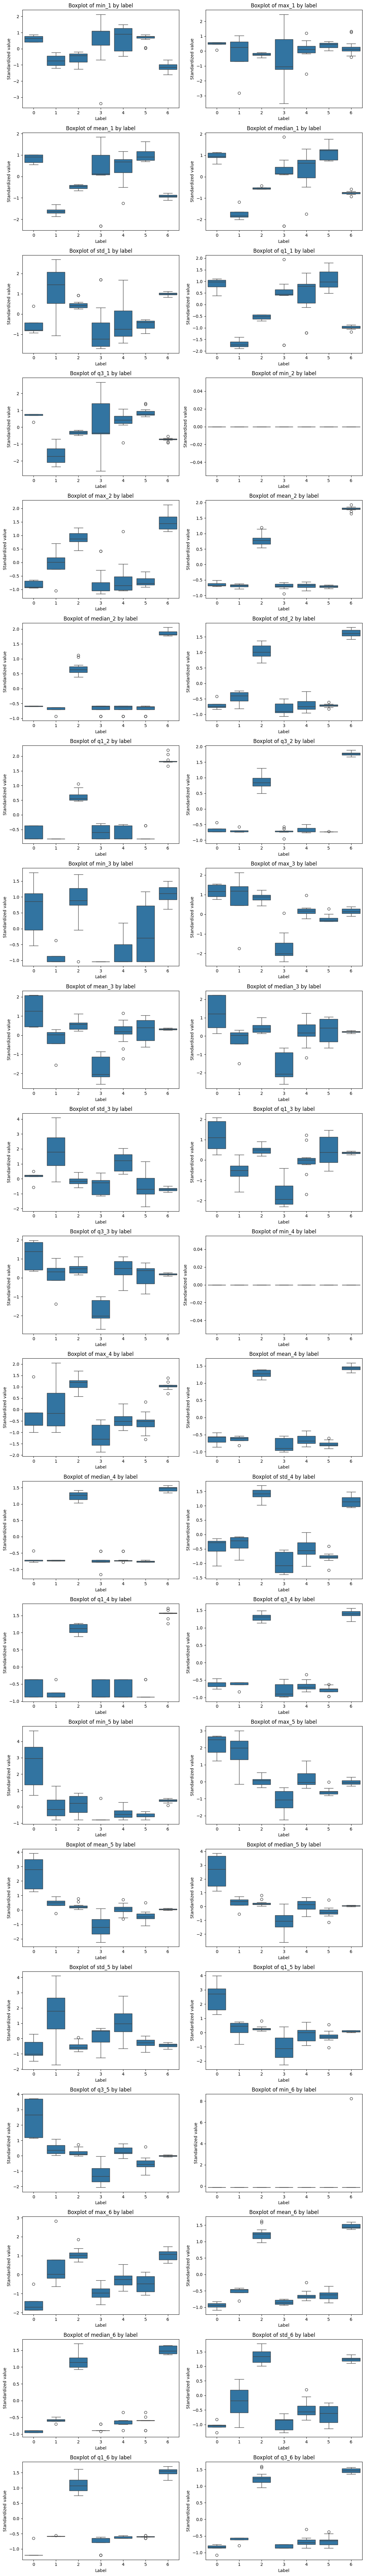

In [12]:
features = df_train_scaled.drop(columns='label').columns
label_col = 'label'

n_cols = 2
n_features = len(features)
n_rows = (n_features + n_cols - 1) // n_cols

plt.figure(figsize=(12, 4 * n_rows))

for i, f in enumerate(features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x=label_col, y=f, data=df_train_scaled)
    plt.title(f'Boxplot of {f} by label')
    plt.xlabel('Label')
    plt.ylabel('Standardized value')

plt.tight_layout()
plt.show()

By boxplotting the distribution of each feature across different classes using boxplots, we can tell that the following features exhibit relatively wide spread and clear separation between labels:

mean_1, median_1, q3_1, min_3, max_3, q1_3, max_5, mean_5, median_5, max_6, mean_6.

These features are likely to have strong discriminative power and therefore become the primary focus of our subsequent analysis.

To systematically evaluate the contribution of each feature to class differentiation, we will apply ANOVA F-score using SelectKBest from scikit-learn. And we calculate F-scores by feature type (e.g., mean, median, q1/q3) to assess the overall importance of each type.

Type
mean      368.170192
q3        350.436027
median    317.745043
q1        154.114553
std       109.167132
max        30.030112
min        14.638533
Name: F-Score, dtype: float64


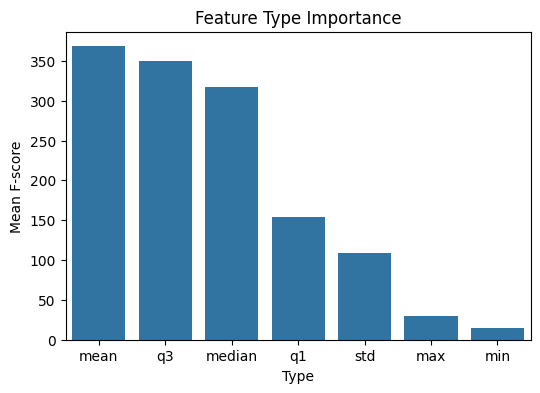

In [13]:
X = df_train_scaled.drop(columns='label')
y = df_train_scaled['label']

sel_var = VarianceThreshold(threshold=0.0)  # Remove features with 0 variance to avoid warning
X_nonconstant = pd.DataFrame(sel_var.fit_transform(X),
                             columns=X.columns[sel_var.get_support()])

# Select 3 most important features
selector = SelectKBest(score_func=f_classif, k=3)
X_selected = selector.fit_transform(X_nonconstant, y)

# Calculate F-score and p-value for each single feature
feature_scores = pd.DataFrame({
    'Feature': X_nonconstant.columns,   # Sample: mean_1
    'Type': X_nonconstant.columns.str.split('_').str[0],    # Sample: mean
    'F-Score': selector.scores_,
    'p-value': selector.pvalues_
}).sort_values(by='F-Score', ascending=False)

# Drop values with NaN F-score
feature_scores = feature_scores.dropna(subset=['F-Score'])

# Group features by their types
type_scores = feature_scores.groupby('Type')['F-Score'].mean().sort_values(ascending=False)
print(type_scores)

plt.figure(figsize=(6,4))
sns.barplot(x=type_scores.index, y=type_scores.values)
plt.ylabel("Mean F-score")
plt.title("Feature Type Importance")
plt.show()

As the graph indicates, **mean**, **q3** and **median** have the highest F-score among all the features. This means these 3 features have the most discriminative information for classification in the model. And the result is also aligned with what we see from the boxplot.

## 2. ISLR 3.7.4

I collect a set of data (n = 100 observations) containing a single predictor and a quantitative response. I then fit a linear regression model to the data, as well as a separate cubic regression, i.e. Y=β0 + β1X + β2X2 + β3X3 + ϵ.

### (a) Linear Train

**Q:** Suppose that the true relationship between X and Y is linear, i.e. Y= β0 + β1X + ϵ. Consider the training residual sum of squares (RSS) for the linear regression, and also the training RSS for the cubic regression. Would we expect one to be lower than the other, would we expect them to be the same, or is there not enough information to tell? Justify your answer.

**A:** The training RSS for the cubic regression will be lower than or equal to the training RSS for linear regression.

Because the cubic regression has more predictors than linear regression, the cubic model has more flexibility and will perform better in the training set no matter what is the true relationship. Except the case that the estimated β2 and β3 are 0, where cubic and linear model will have equal RSS, cubic model will always have lower RSS.

### (b) Linear Test


**Q:** Answer (a) using test rather than training RSS.

**A:** The test RSS for the cubic regression will be higher than the test RSS for linear regression.

Because the true relationship, the linear model has the correct format to predict the data. So it has lower bias and lower variance. When it comes to cubic regression, it includes the correct format and two more extra predictors($X^2$ and $X^3$). On the test data, these extra predictors will increase variance but not reduce the bias. The cubic model will be overfitting. So the test RSS of cubic regression model will be higher than the linear model's.

### (c) Not Linear Train

**Q:** Suppose that the true relationship between X and Y is not linear, but we don’t know how far it is from linear. Consider the training RSS for the linear regression, and also the training RSS for the cubic regression. Would we expect one to be lower than the other, would we expect them to be the same, or is there not enough information to tell? Justify your answer.

**A:** The test RSS for the cubic regression will be lower than or equal to the test RSS for linear regression.

On the test data, model with more flexibity and more complexity will perform better. Unless β2 and β3 are 0, which means the two models are identical, the cubic model will perform better than linear model. 

### (d) Not Linear Testing

**Q:** Answer (c) using test rather than training RSS.

**A:** There is not enough information to tell which one will perform better.

Since we don't know the true relationship, we cannot predict the performance. The linear model will have higher bias but lower variance. The cubic model will have lower bias but higher variance. The performance will depend on the noise level of the data and the level of nonlinearity between X and Y.

### References:

1. https://docs.python.org/3/library/pathlib.html
2. https://www.geeksforgeeks.org/deep-learning/time-series-classification/
3. https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
4. https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bootstrap.html
5. https://medium.com/@nirajan_DataAnalyst/understanding-feature-selection-techniques-in-machine-learning-02e2642ef63e
6. https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.VarianceThreshold.html
7. https://statisticsbyjim.com/regression/residual-sum-of-squares-rss/